# Our Simple Training and Evaluation Script

- First, we will load simple python libraries that should come preloaded.

In [1]:
import os
import torch

from torch_brain.utils import seed_everything

In [2]:
seed_everything(0)

base_dir = os.getcwd().split("notebooks")[0]
device = "callable" if torch.cuda.is_available() else "cpu"

print(f"Using: {device}")

Using: cpu


## Loading the Data

In [3]:
from neural_decode.dataset.transformer_dataloader import get_train_val_loaders

In [4]:
path_to_neural_dataset = os.path.join(base_dir, "data", "perich_miller_population_2018", "t_20130819_center_out_reaching")
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(path_to_neural_dataset, batch_size=64)

num_units = len(train_dataset.get_unit_ids())
print(f"Num Units in Session: {num_units}")

Num Units in Session: 55


## Loading a Model

In [5]:
from neural_decode.models.transformer import TransformerNeuralDecoder 

In [6]:
# 2. Initialize Model
tf_model = TransformerNeuralDecoder(
    num_units=num_units,    # Num. of units inputted (spiking activity)
    #
    bin_size=10e-3,         # Duration (s) of bins
    sequence_length=1.0,    # Context length of the model
    #
    dim_output=2,           # Output dimension of final readout layer
    dim_hidden=128,         # Hidden dimension of the model
    n_layers=3,             # Num. of transformer layers
    n_heads=4,
).to(device)

## Training a Model

In [7]:
from neural_decode.training.train_model import train

In [8]:
train_dataset.transform = tf_model.tokenize
val_dataset.transform = tf_model.tokenize

optimizer = torch.optim.AdamW(tf_model.parameters(), lr=1e-3)

In [9]:
transformer_r2_log, transformer_loss_log, transformer_train_outputs = train(tf_model, optimizer, train_loader, val_loader,
                                                                            num_epochs=10, device = device)

Epoch 10/10 | Val R2 = 0.165 | Loss = 13.657
Done! Final validation R2 = 0.253


## Evaluating a Model

In [10]:
from neural_decode.evaluation.graphing_functions import plot_training_curves

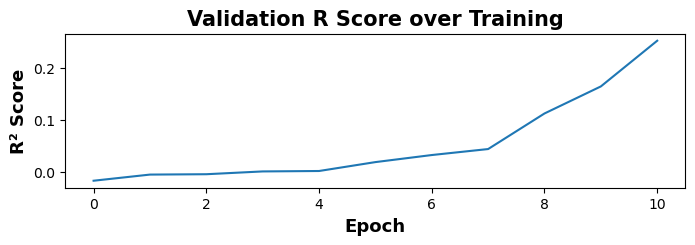

In [12]:
fig_plot = plot_training_curves(transformer_r2_log)